# Revelio `in_us` sensitivity checks

This notebook compares the Revelio `in_us` pooled horizon result across the dimensions that changed in the slide rebuild:

- sample/event source cache: old econ-only, old full-sample, current full-sample
- aggregation: row-level slide-style, collapsed cell unweighted, collapsed cell weighted by graduates
- horizon support: `0..4` versus `0..5`
- relabel cohorts: old `2015..2019`, new `2014..2020`, and related bounds
- post event-time support: slide-style `t=-1..+5` versus restricted `t=-1..+3`

The regression below is the pooled treat x post horizon regression for `in_us` only:

`in_us ~ post_ind + post_ind:treated_ind | unitid x broad_pair_bin x degree_type + grad_year`, clustered by `unitid`.

That is equivalent to the slide pooled-post design, but uses `pyfixest` when available so the sensitivity grid runs faster on the full-sample panels. It falls back to `statsmodels` if needed.


## Generated plots from the last run

These are saved by the plotting cells and embedded here as static notebook images.

![One-change-at-a-time in_us sensitivity](../output/relabel_indiv/laborlunch_20260507_individual_cache/in_us_sensitivity/one_change_at_a_time_in_us_sensitivity.png)

![Current settings by aggregation type](../output/relabel_indiv/laborlunch_20260507_individual_cache/in_us_sensitivity/current_settings_by_aggregation_type.png)

![Relabel span sensitivity](../output/relabel_indiv/laborlunch_20260507_individual_cache/in_us_sensitivity/relabel_span_sensitivity.png)

![Post event-time span sensitivity](../output/relabel_indiv/laborlunch_20260507_individual_cache/in_us_sensitivity/post_event_time_span_sensitivity.png)


In [17]:
from __future__ import annotations

from pathlib import Path
import itertools
import math
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HOME = Path.home()
CODE_ROOT = HOME / "h1bworkers" / "code"
if str(CODE_ROOT) not in sys.path:
    sys.path.insert(0, str(CODE_ROOT))

from relabels_revelio import build_laborlunch_20260507_individual_effects as builder
from relabels_revelio import relabel_indiv_analysis as indiv

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

OUTCOME = "in_us"
CACHE_DIR = builder.DEFAULT_CACHE_DIR
NOTEBOOK_OUT = CODE_ROOT / "output" / "relabel_indiv" / "laborlunch_20260507_individual_cache" / "in_us_sensitivity"
NOTEBOOK_OUT.mkdir(parents=True, exist_ok=True)
NOTEBOOK_OUT


PosixPath('/home/yk0581/h1bworkers/code/output/relabel_indiv/laborlunch_20260507_individual_cache/in_us_sensitivity')

## Panel catalog

The named caches below are the useful comparison points from the current cache directory, including the latest econ-only rebuild. If one is missing, the grid will skip it.


In [18]:
PANEL_CATALOG = {
    "econ_only_old_2015_2019_h0_5": CACHE_DIR / "revelio_final_panel_econ_only_never_treated_19fdaddbc86d3754.parquet",
    "econ_only_current_2015_2019_h0_4": CACHE_DIR / "revelio_final_panel_econ_only_never_treated_ffd1c2adbd46e49b.parquet",
    "full_sample_old_2014_2021_h0_5": CACHE_DIR / "revelio_final_panel_full_sample_never_treated_b4221392fb097b5c.parquet",
    "full_sample_current_2014_2020_h0_4": CACHE_DIR / "revelio_final_panel_full_sample_never_treated_d2b092d5d3984d89.parquet",
}

panel_status = pd.DataFrame(
    [
        {
            "panel_key": key,
            "path": str(path),
            "exists": path.exists(),
            "size_mb": path.stat().st_size / 1e6 if path.exists() else np.nan,
        }
        for key, path in PANEL_CATALOG.items()
    ]
)
panel_status


,panel_key,path,exists,size_mb
0,econ_only_old_2015_2019_h0_5,/home/yk0581/h1bworkers/code/output/relabel_in...,True,2.289960
1,econ_only_current_2015_2019_h0_4,/home/yk0581/h1bworkers/code/output/relabel_in...,True,2.361345
2,full_sample_old_2014_2021_h0_5,/home/yk0581/h1bworkers/code/output/relabel_in...,True,54.108326
3,full_sample_current_2014_2020_h0_4,/home/yk0581/h1bworkers/code/output/relabel_in...,True,42.763088


In [19]:
try:
    import pyarrow.parquet as pq
except Exception as exc:
    pq = None
    print(f"pyarrow schema reads unavailable: {exc}")

NEEDED_COLUMNS = [
    "analysis_variant",
    "user_id",
    "education_number",
    "unitid",
    "relabel_year",
    "treated_ind",
    "cohort_t",
    "grad_year",
    "horizon_years",
    "target_year",
    "target_year_observed",
    "event_id",
    "broad_pair_bin",
    "degree_type",
    OUTCOME,
]

_panel_cache: dict[str, pd.DataFrame] = {}

def parquet_columns(path: Path) -> list[str]:
    if pq is not None:
        return list(pq.read_schema(path).names)
    # Fallback: read a tiny subset of known required columns.
    return NEEDED_COLUMNS


def load_panel(panel_key: str) -> pd.DataFrame:
    if panel_key in _panel_cache:
        return _panel_cache[panel_key]
    path = PANEL_CATALOG[panel_key]
    if not path.exists():
        raise FileNotFoundError(path)
    cols = [col for col in NEEDED_COLUMNS if col in parquet_columns(path)]
    df = pd.read_parquet(path, columns=cols)
    for col in ["unitid", "relabel_year", "treated_ind", "cohort_t", "grad_year", "horizon_years", "target_year", "target_year_observed"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    _panel_cache[panel_key] = df
    return df


def summarize_panel(panel_key: str) -> dict[str, object]:
    df = load_panel(panel_key)
    return {
        "panel_key": panel_key,
        "rows": len(df),
        "variants": sorted(df["analysis_variant"].dropna().astype(str).unique().tolist()),
        "relabel_min": int(df["relabel_year"].min()),
        "relabel_max": int(df["relabel_year"].max()),
        "horizons": sorted(df["horizon_years"].dropna().astype(int).unique().tolist()),
        "event_t_min": int(df["cohort_t"].min()),
        "event_t_max": int(df["cohort_t"].max()),
    }

pd.DataFrame([summarize_panel(k) for k, p in PANEL_CATALOG.items() if p.exists()])


,panel_key,rows,variants,relabel_min,relabel_max,horizons,event_t_min,event_t_max
0,econ_only_old_2015_2019_h0_5,139152,"[foia_linked_person_baseline, stage04_all]",2015,2019,"[0, 1, 2, 3, 4, 5]",-5,5
1,econ_only_current_2015_2019_h0_4,115960,"[foia_linked_person_baseline, stage04_all]",2015,2019,"[0, 1, 2, 3, 4]",-5,5
2,full_sample_old_2014_2021_h0_5,3742218,"[foia_linked_person_baseline, stage04_all]",2014,2021,"[0, 1, 2, 3, 4, 5]",-5,5
3,full_sample_current_2014_2020_h0_4,2523680,"[foia_linked_person_baseline, stage04_all]",2014,2020,"[0, 1, 2, 3, 4]",-5,5


## Regression helpers

`aggregation` has three settings:

- `user_rows_unweighted`: use the row-level panel, matching the slide pooled-post regression most closely.
- `cell_unweighted`: collapse to unit x relabel cohort x event-time x horizon x broad-bin x degree cells, then OLS unweighted.
- `cell_total_grads_weighted`: same cell collapse, then WLS/FE weights by the number of distinct users in the cell.

`post_max` controls how far forward the post window runs. The current slide pooled-post TWFE path uses `post_max=5` when `event_window=5`; the requested restriction is represented by `post_max=3`.


In [20]:
AGG_USER = "user_rows_unweighted"
AGG_CELL = "cell_unweighted"
AGG_CELL_W = "cell_total_grads_weighted"
AGGREGATIONS = [AGG_USER, AGG_CELL, AGG_CELL_W]


def _ensure_string_col(df: pd.DataFrame, col: str, default: str) -> pd.Series:
    if col in df.columns:
        return df[col].fillna(default).astype(str)
    return pd.Series(default, index=df.index, dtype="object")


def prepare_regression_frame(
    panel: pd.DataFrame,
    *,
    analysis_variant: str,
    horizons: list[int],
    relabel_span: tuple[int, int],
    pre_min: int,
    post_max: int,
    aggregation: str,
) -> pd.DataFrame:
    work = panel.copy()
    work = work[work["analysis_variant"].astype(str).eq(analysis_variant)].copy()
    work = work[work["horizon_years"].isin([int(h) for h in horizons])].copy()
    work = work[work["relabel_year"].between(int(relabel_span[0]), int(relabel_span[1]))].copy()
    work = work[work["cohort_t"].between(int(pre_min), int(post_max))].copy()
    if "target_year_observed" in work.columns:
        work = work[work["target_year_observed"].fillna(1).eq(1)].copy()
    work = work.dropna(subset=[OUTCOME, "unitid", "treated_ind", "cohort_t", "grad_year", "horizon_years", "relabel_year"])
    if work.empty:
        return work

    if aggregation in {AGG_CELL, AGG_CELL_W}:
        group_cols = ["unitid", "relabel_year", "treated_ind", "cohort_t", "grad_year", "horizon_years"]
        for col in ["event_id", "broad_pair_bin", "degree_type"]:
            if col in work.columns:
                group_cols.append(col)
        grouped = (
            work.groupby(group_cols, as_index=False, dropna=False)
            .agg(
                in_us=(OUTCOME, "mean"),
                total_grads=("user_id", "nunique") if "user_id" in work.columns else (OUTCOME, "size"),
            )
        )
        work = grouped
    else:
        work["total_grads"] = 1.0

    for col in ["unitid", "relabel_year", "treated_ind", "cohort_t", "grad_year", "horizon_years"]:
        work[col] = pd.to_numeric(work[col], errors="coerce")
    work = work.dropna(subset=["unitid", "relabel_year", "treated_ind", "cohort_t", "grad_year", "horizon_years", OUTCOME])
    work["unitid"] = work["unitid"].astype("int64")
    work["treated_ind"] = work["treated_ind"].astype("int64")
    work["cohort_t"] = work["cohort_t"].astype("int64")
    work["grad_year"] = work["grad_year"].astype("int64")
    work["horizon_years"] = work["horizon_years"].astype("int64")
    work["post_ind"] = work["cohort_t"].ge(-1).astype("int64")
    work["cluster_unitid"] = work["unitid"].astype("int64")
    broad = _ensure_string_col(work, "broad_pair_bin", "missing")
    degree = _ensure_string_col(work, "degree_type", "missing")
    work["did_fe_group"] = work["unitid"].astype(str) + "||" + broad + "||" + degree
    work["reg_weight"] = pd.to_numeric(work["total_grads"], errors="coerce").fillna(0.0).clip(lower=0.0)
    if aggregation != AGG_CELL_W:
        work["reg_weight"] = 1.0
    return work


def support_summary(work: pd.DataFrame) -> dict[str, object]:
    if work.empty:
        return {"n_rows": 0}
    treated = work[work["treated_ind"].eq(1)]
    return {
        "n_rows": len(work),
        "n_treated_rows": int(work["treated_ind"].sum()),
        "n_unitids": int(work["unitid"].nunique()),
        "n_fe": int(work["did_fe_group"].nunique()),
        "relabel_min": int(work["relabel_year"].min()),
        "relabel_max": int(work["relabel_year"].max()),
        "event_min": int(work["cohort_t"].min()),
        "event_max": int(work["cohort_t"].max()),
        "treated_total_grads": float(treated["reg_weight"].sum()),
    }


In [21]:
def fit_pooled_in_us_one_horizon(sub: pd.DataFrame, *, aggregation: str) -> dict[str, object]:
    if sub.empty:
        return {"status": "empty"}
    if sub["treated_ind"].nunique() < 2 or sub["post_ind"].nunique() < 2:
        return {"status": "insufficient_treated_or_post_variation", **support_summary(sub)}
    for treated_value in [0, 1]:
        for post_value in [0, 1]:
            if sub[sub["treated_ind"].eq(treated_value) & sub["post_ind"].eq(post_value)].empty:
                return {"status": "missing_did_cell", **support_summary(sub)}

    formula_fixest = "in_us ~ post_ind + post_ind:treated_ind | did_fe_group + grad_year"
    formula_sm = "in_us ~ post_ind + post_ind:treated_ind + C(did_fe_group) + C(grad_year)"
    weighted = aggregation == AGG_CELL_W
    try:
        from pyfixest.estimation import feols
        kwargs = {
            "fml": formula_fixest,
            "data": sub,
            "vcov": {"CRV1": "cluster_unitid"},
            "copy_data": False,
            "store_data": False,
        }
        if weighted:
            kwargs["weights"] = "reg_weight"
        result = feols(**kwargs)
        params, cov = builder.estimator_cmp._result_params_and_cov(result)  # noqa: SLF001
        param = "post_ind:treated_ind"
        coef = float(params.get(param, np.nan))
        se = float(math.sqrt(max(float(cov.loc[param, param]), 0.0))) if param in cov.index else np.nan
        backend = "pyfixest"
    except Exception as exc:
        import statsmodels.formula.api as smf
        try:
            if weighted:
                model = smf.wls(formula_sm, data=sub, weights=sub["reg_weight"])
            else:
                model = smf.ols(formula_sm, data=sub)
            result = model.fit(cov_type="cluster", cov_kwds={"groups": sub["cluster_unitid"]})
            param = "post_ind:treated_ind"
            coef = float(result.params.get(param, np.nan))
            se = float(result.bse.get(param, np.nan))
            backend = f"statsmodels_fallback_after_{type(exc).__name__}"
        except Exception as exc2:
            return {"status": f"regression_failed: {type(exc2).__name__}: {exc2}", **support_summary(sub)}

    treated_pre = sub.loc[sub["treated_ind"].eq(1) & sub["post_ind"].eq(0), OUTCOME]
    treated_post = sub.loc[sub["treated_ind"].eq(1) & sub["post_ind"].eq(1), OUTCOME]
    control_pre = sub.loc[sub["treated_ind"].eq(0) & sub["post_ind"].eq(0), OUTCOME]
    control_post = sub.loc[sub["treated_ind"].eq(0) & sub["post_ind"].eq(1), OUTCOME]
    raw_did = (treated_post.mean() - treated_pre.mean()) - (control_post.mean() - control_pre.mean())
    return {
        "status": "ok",
        "backend": backend,
        "coef": coef,
        "se": se,
        "ci_lower": coef - 1.96 * se if pd.notna(coef) and pd.notna(se) else np.nan,
        "ci_upper": coef + 1.96 * se if pd.notna(coef) and pd.notna(se) else np.nan,
        "raw_did": float(raw_did),
        "treated_pre_mean": float(treated_pre.mean()),
        "treated_post_mean": float(treated_post.mean()),
        "control_pre_mean": float(control_pre.mean()),
        "control_post_mean": float(control_post.mean()),
        **support_summary(sub),
    }


def run_spec(spec: dict[str, object]) -> pd.DataFrame:
    panel_key = str(spec["panel_key"])
    if not PANEL_CATALOG[panel_key].exists():
        return pd.DataFrame([{**spec, "status": "missing_panel_cache"}])
    panel = load_panel(panel_key)
    horizons = list(spec["horizons"])
    work = prepare_regression_frame(
        panel,
        analysis_variant=str(spec["analysis_variant"]),
        horizons=horizons,
        relabel_span=tuple(spec["relabel_span"]),
        pre_min=int(spec.get("pre_min", -5)),
        post_max=int(spec["post_max"]),
        aggregation=str(spec["aggregation"]),
    )
    rows = []
    for horizon in horizons:
        sub = work[work["horizon_years"].eq(int(horizon))].copy() if not work.empty else work
        row = fit_pooled_in_us_one_horizon(sub, aggregation=str(spec["aggregation"]))
        row.update(spec)
        row["horizon_years"] = int(horizon)
        rows.append(row)
    return pd.DataFrame(rows)


def run_specs(specs: list[dict[str, object]]) -> pd.DataFrame:
    frames = []
    for i, spec in enumerate(specs, start=1):
        print(f"[{i}/{len(specs)}] {spec['label']}")
        frames.append(run_spec(spec))
    out = pd.concat(frames, ignore_index=True, sort=False) if frames else pd.DataFrame()
    if not out.empty:
        out.to_csv(NOTEBOOK_OUT / "in_us_sensitivity_results.csv", index=False)
    return out


## One-change-at-a-time comparison

This grid is intentionally small. It starts from the old econ-only cache and then changes one dimension at a time toward the current full-sample settings.


In [22]:
ONE_AT_A_TIME_SPECS = [
    {
        "label": "01_old_econ_h0_5_relabel2015_2019_post5_user_rows",
        "panel_key": "econ_only_old_2015_2019_h0_5",
        "analysis_variant": "stage04_all",
        "aggregation": AGG_USER,
        "horizons": [0, 1, 2, 3, 4, 5],
        "relabel_span": (2015, 2019),
        "pre_min": -5,
        "post_max": 5,
    },
    {
        "label": "02_old_econ_h0_4_only",
        "panel_key": "econ_only_old_2015_2019_h0_5",
        "analysis_variant": "stage04_all",
        "aggregation": AGG_USER,
        "horizons": [0, 1, 2, 3, 4],
        "relabel_span": (2015, 2019),
        "pre_min": -5,
        "post_max": 5,
    },
    {
        "label": "03_old_econ_post3_only",
        "panel_key": "econ_only_old_2015_2019_h0_5",
        "analysis_variant": "stage04_all",
        "aggregation": AGG_USER,
        "horizons": [0, 1, 2, 3, 4],
        "relabel_span": (2015, 2019),
        "pre_min": -5,
        "post_max": 3,
    },
    {
        "label": "04_current_econ_rebuild_2015_2019_h0_4_post3",
        "panel_key": "econ_only_current_2015_2019_h0_4",
        "analysis_variant": "stage04_all",
        "aggregation": AGG_USER,
        "horizons": [0, 1, 2, 3, 4],
        "relabel_span": (2015, 2019),
        "pre_min": -5,
        "post_max": 3,
    },
    {
        "label": "05_full_sample_same_relabel2015_2019_post3",
        "panel_key": "full_sample_old_2014_2021_h0_5",
        "analysis_variant": "stage04_all",
        "aggregation": AGG_USER,
        "horizons": [0, 1, 2, 3, 4],
        "relabel_span": (2015, 2019),
        "pre_min": -5,
        "post_max": 3,
    },
    {
        "label": "06_full_sample_expand_relabel2014_2020_post3",
        "panel_key": "full_sample_old_2014_2021_h0_5",
        "analysis_variant": "stage04_all",
        "aggregation": AGG_USER,
        "horizons": [0, 1, 2, 3, 4],
        "relabel_span": (2014, 2020),
        "pre_min": -5,
        "post_max": 3,
    },
    {
        "label": "07_current_cache_full_sample_2014_2020_h0_4_post3",
        "panel_key": "full_sample_current_2014_2020_h0_4",
        "analysis_variant": "stage04_all",
        "aggregation": AGG_USER,
        "horizons": [0, 1, 2, 3, 4],
        "relabel_span": (2014, 2020),
        "pre_min": -5,
        "post_max": 3,
    },
]

one_at_a_time = run_specs(ONE_AT_A_TIME_SPECS)
one_at_a_time[["label", "horizon_years", "status", "coef", "se", "raw_did", "n_rows", "n_unitids", "relabel_min", "relabel_max", "event_min", "event_max", "backend"]]


[1/7] 01_old_econ_h0_5_relabel2015_2019_post5_user_rows
[2/7] 02_old_econ_h0_4_only
[3/7] 03_old_econ_post3_only
[4/7] 04_current_econ_rebuild_2015_2019_h0_4_post3
[5/7] 05_full_sample_same_relabel2015_2019_post3
[6/7] 06_full_sample_expand_relabel2014_2020_post3
[7/7] 07_current_cache_full_sample_2014_2020_h0_4_post3


,label,horizon_years,status,coef,se,raw_did,n_rows,n_unitids,relabel_min,relabel_max,event_min,event_max,backend
0,01_old_econ_h0_5_relabel2015_2019_post5_user_rows,0,ok,0.072315,0.046858,0.064546,17895,40,2015,2019,-5,5,pyfixest
1,01_old_econ_h0_5_relabel2015_2019_post5_user_rows,1,ok,0.068330,0.047552,0.063091,17895,40,2015,2019,-5,5,pyfixest
2,01_old_econ_h0_5_relabel2015_2019_post5_user_rows,2,ok,0.070267,0.043705,0.066619,17895,40,2015,2019,-5,5,pyfixest
3,01_old_econ_h0_5_relabel2015_2019_post5_user_rows,3,ok,0.056955,0.045186,0.052425,17711,40,2015,2019,-5,5,pyfixest
4,01_old_econ_h0_5_relabel2015_2019_post5_user_rows,4,ok,0.046871,0.042539,0.042544,17007,40,2015,2019,-5,5,pyfixest
5,01_old_econ_h0_5_relabel2015_2019_post5_user_rows,5,ok,0.046680,0.041107,0.040444,15610,40,2015,2019,-5,5,pyfixest
6,02_old_econ_h0_4_only,0,ok,0.072315,0.046858,0.064546,17895,40,2015,2019,-5,5,pyfixest
7,02_old_econ_h0_4_only,1,ok,0.068330,0.047552,0.063091,17895,40,2015,2019,-5,5,pyfixest
8,02_old_econ_h0_4_only,2,ok,0.070267,0.043705,0.066619,17895,40,2015,2019,-5,5,pyfixest
9,02_old_econ_h0_4_only,3,ok,0.056955,0.045186,0.052425,17711,40,2015,2019,-5,5,pyfixest


Saved plot: /home/yk0581/h1bworkers/code/output/relabel_indiv/laborlunch_20260507_individual_cache/in_us_sensitivity/one_change_at_a_time_in_us_sensitivity.png


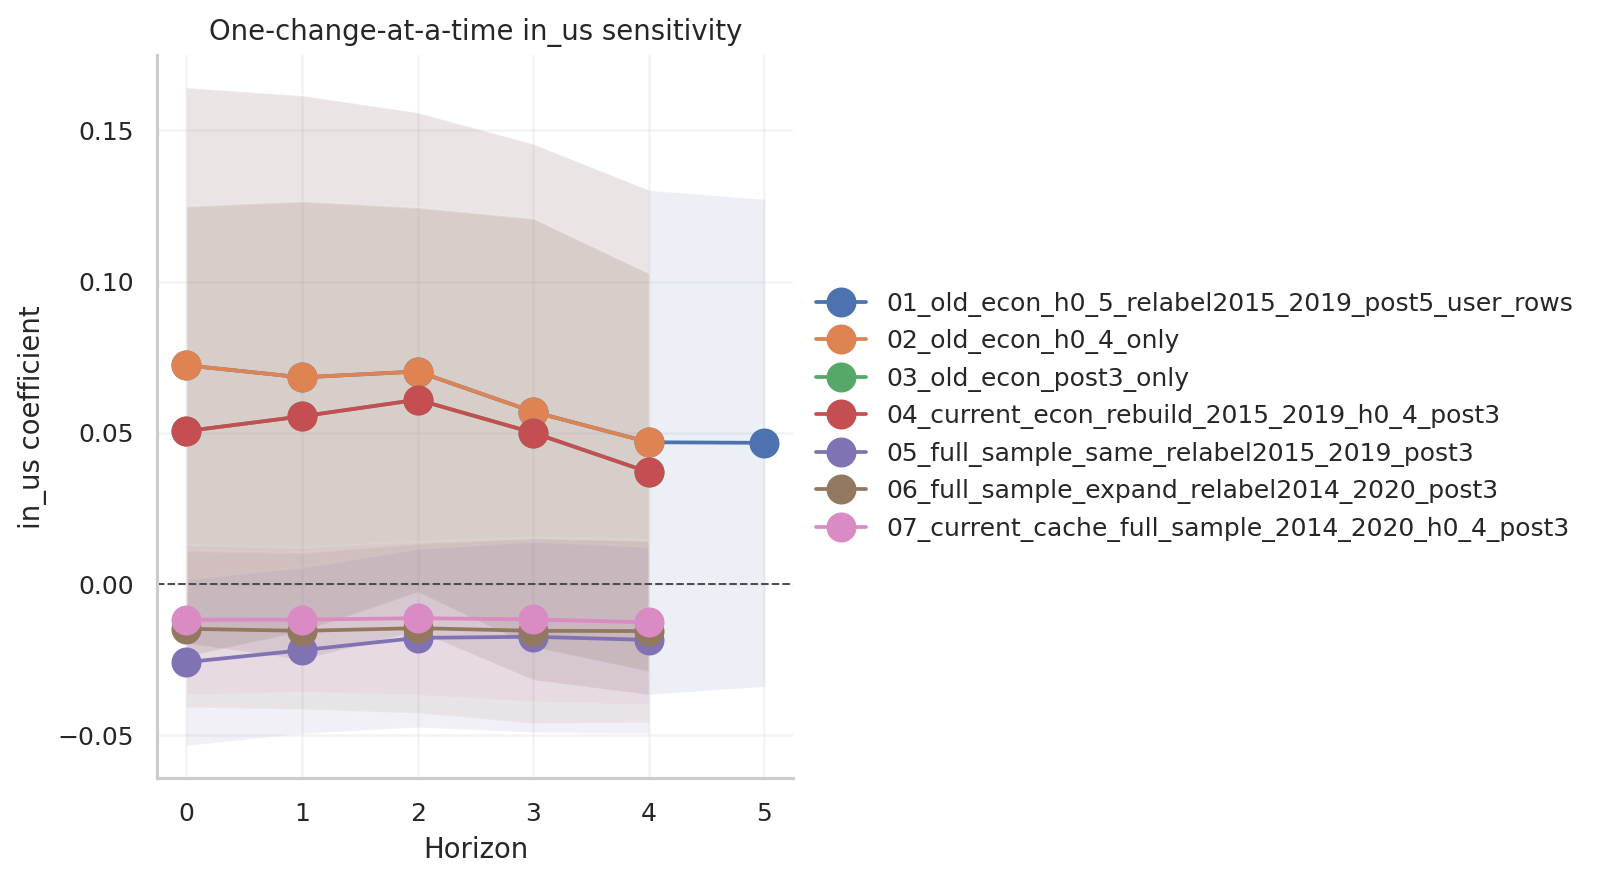

PosixPath('/home/yk0581/h1bworkers/code/output/relabel_indiv/laborlunch_20260507_individual_cache/in_us_sensitivity/one_change_at_a_time_in_us_sensitivity.png')

In [23]:
from IPython.display import Image as IPyImage, display

def plot_profiles(df: pd.DataFrame, *, title: str, labels: list[str] | None = None, filename: str | None = None) -> Path | None:
    work = df[df["status"].eq("ok")].copy()
    if labels is not None:
        work = work[work["label"].isin(labels)].copy()
    if work.empty:
        print("No ok rows to plot.")
        return None
    fig, ax = plt.subplots(figsize=(9, 5))
    for label, grp in work.groupby("label", sort=False):
        grp = grp.sort_values("horizon_years")
        ax.plot(grp["horizon_years"], grp["coef"], marker="o", label=label)
        if "se" in grp:
            ax.fill_between(
                grp["horizon_years"].to_numpy(dtype=float),
                (grp["coef"] - 1.96 * grp["se"]).to_numpy(dtype=float),
                (grp["coef"] + 1.96 * grp["se"]).to_numpy(dtype=float),
                alpha=0.10,
            )
    ax.axhline(0, color="0.3", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Horizon")
    ax.set_ylabel("in_us coefficient")
    ax.set_title(title)
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
    fig.tight_layout()
    if filename is None:
        filename = ''.join(ch.lower() if ch.isalnum() else '_' for ch in title).strip('_') + '.png'
    out_path = NOTEBOOK_OUT / filename
    fig.savefig(out_path, dpi=180, bbox_inches='tight')
    print(f'Saved plot: {out_path}')
    display(IPyImage(filename=str(out_path)))
    plt.show()
    return out_path

plot_profiles(one_at_a_time, title="One-change-at-a-time in_us sensitivity")


## Aggregation comparison at current sample settings

This isolates whether row-level versus cell-level and graduate weighting changes the result.


In [24]:
AGGREGATION_SPECS = [
    {
        "label": f"{panel_label}_{aggregation}",
        "panel_key": panel_key,
        "analysis_variant": "stage04_all",
        "aggregation": aggregation,
        "horizons": [0, 1, 2, 3, 4],
        "relabel_span": relabel_span,
        "pre_min": -5,
        "post_max": 3,
    }
    for panel_label, panel_key, relabel_span in [
        ("current_econ", "econ_only_current_2015_2019_h0_4", (2015, 2019)),
        ("current_full", "full_sample_current_2014_2020_h0_4", (2014, 2020)),
    ]
    for aggregation in AGGREGATIONS
]

aggregation_results = run_specs(AGGREGATION_SPECS)
aggregation_results[["label", "horizon_years", "status", "coef", "se", "raw_did", "n_rows", "n_unitids", "treated_total_grads", "backend"]]


[1/6] current_econ_user_rows_unweighted
[2/6] current_econ_cell_unweighted
[3/6] current_econ_cell_total_grads_weighted
[4/6] current_full_user_rows_unweighted
[5/6] current_full_cell_unweighted
[6/6] current_full_cell_total_grads_weighted


,label,horizon_years,status,coef,se,raw_did,n_rows,n_unitids,treated_total_grads,backend
0,current_econ_user_rows_unweighted,0,ok,0.050551,0.037961,0.047964,14737,40,8805.0,pyfixest
1,current_econ_user_rows_unweighted,1,ok,0.055442,0.036307,0.053972,14737,40,8805.0,pyfixest
2,current_econ_user_rows_unweighted,2,ok,0.060938,0.032447,0.060768,14737,40,8805.0,pyfixest
3,current_econ_user_rows_unweighted,3,ok,0.050029,0.036160,0.048651,14737,40,8805.0,pyfixest
4,current_econ_user_rows_unweighted,4,ok,0.036954,0.033608,0.037937,14737,40,8805.0,pyfixest
5,current_econ_cell_unweighted,0,ok,0.005226,0.036358,0.007978,386,40,189.0,pyfixest
6,current_econ_cell_unweighted,1,ok,0.037377,0.031890,0.042070,386,40,189.0,pyfixest
7,current_econ_cell_unweighted,2,ok,0.033613,0.029782,0.039585,386,40,189.0,pyfixest
8,current_econ_cell_unweighted,3,ok,0.017898,0.031373,0.022701,386,40,189.0,pyfixest
9,current_econ_cell_unweighted,4,ok,0.010702,0.034621,0.014520,386,40,189.0,pyfixest


Saved plot: /home/yk0581/h1bworkers/code/output/relabel_indiv/laborlunch_20260507_individual_cache/in_us_sensitivity/current_settings_by_aggregation_type.png


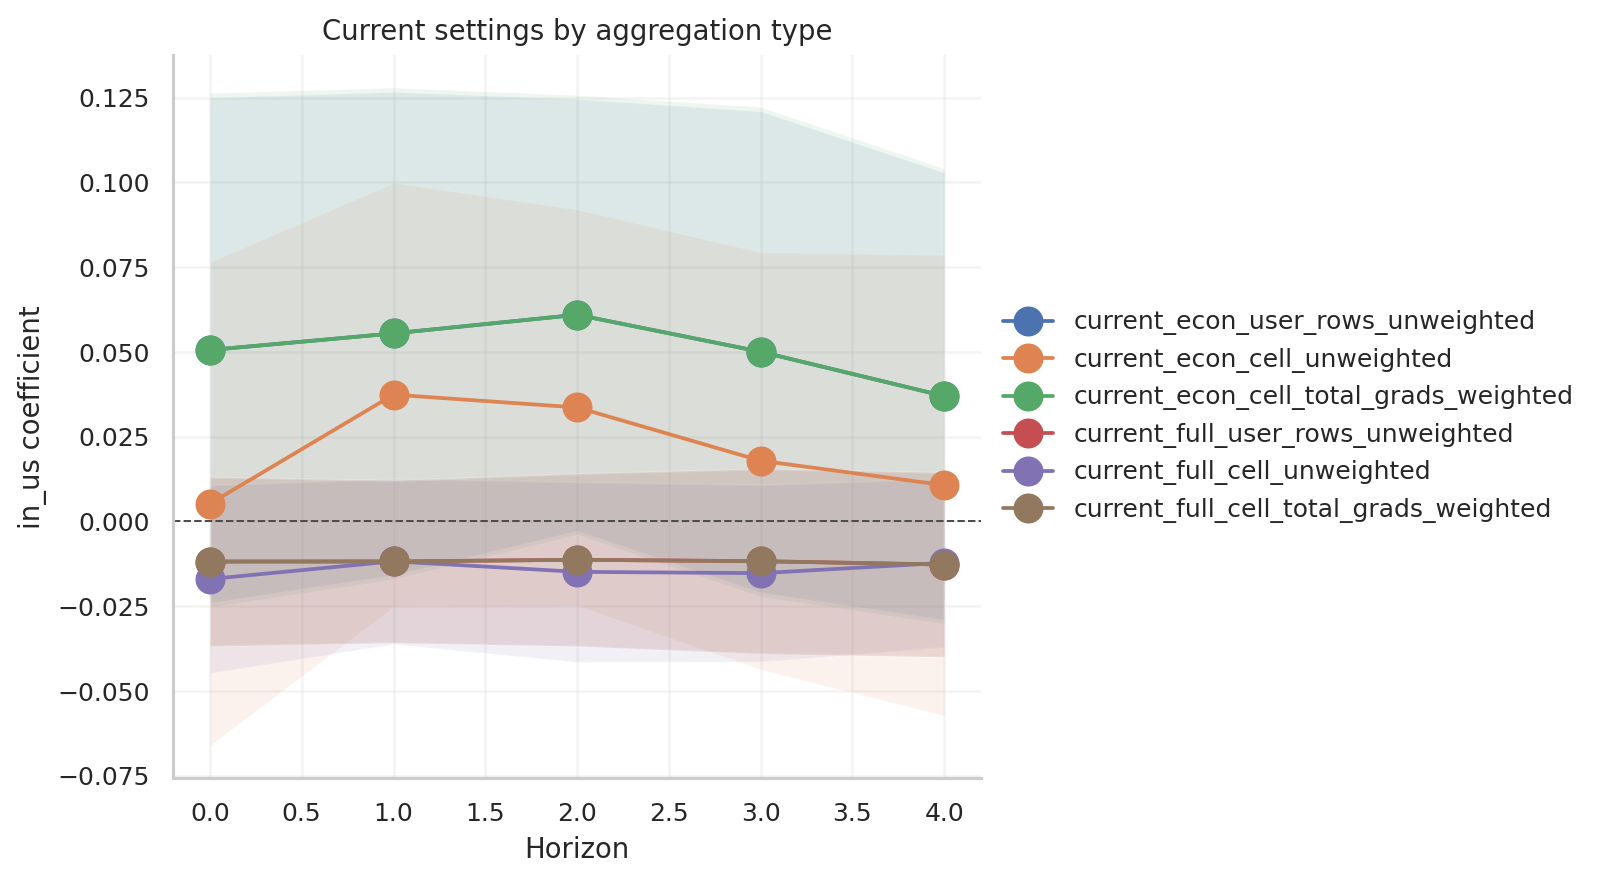

PosixPath('/home/yk0581/h1bworkers/code/output/relabel_indiv/laborlunch_20260507_individual_cache/in_us_sensitivity/current_settings_by_aggregation_type.png')

In [25]:
plot_profiles(aggregation_results, title="Current settings by aggregation type")


## Relabel span comparison

This uses the old full-sample cache, because it contains 2014-2021 and lets you compare alternative relabel windows from the same underlying panel.


In [26]:
RELABEL_SPANS = {
    "2015_2019_old": (2015, 2019),
    "2014_2019_add_2014": (2014, 2019),
    "2015_2020_add_2020": (2015, 2020),
    "2014_2020_new": (2014, 2020),
    "2014_2021_with_2021": (2014, 2021),
}

RELABEL_SPECS = [
    {
        "label": f"full_sample_relabel_{name}",
        "panel_key": "full_sample_old_2014_2021_h0_5",
        "analysis_variant": "stage04_all",
        "aggregation": AGG_USER,
        "horizons": [0, 1, 2, 3, 4],
        "relabel_span": span,
        "pre_min": -5,
        "post_max": 3,
    }
    for name, span in RELABEL_SPANS.items()
]

relabel_results = run_specs(RELABEL_SPECS)
relabel_results[["label", "horizon_years", "status", "coef", "se", "raw_did", "n_rows", "n_unitids", "relabel_min", "relabel_max", "backend"]]


[1/5] full_sample_relabel_2015_2019_old
[2/5] full_sample_relabel_2014_2019_add_2014
[3/5] full_sample_relabel_2015_2020_add_2020
[4/5] full_sample_relabel_2014_2020_new
[5/5] full_sample_relabel_2014_2021_with_2021


,label,horizon_years,status,coef,se,raw_did,n_rows,n_unitids,relabel_min,relabel_max,backend
0,full_sample_relabel_2015_2019_old,0,ok,-0.025880,0.014038,-0.022209,269452,127,2015,2019,pyfixest
1,full_sample_relabel_2015_2019_old,1,ok,-0.021932,0.014022,-0.018579,269452,127,2015,2019,pyfixest
2,full_sample_relabel_2015_2019_old,2,ok,-0.017831,0.015047,-0.016834,269452,127,2015,2019,pyfixest
3,full_sample_relabel_2015_2019_old,3,ok,-0.017469,0.016088,-0.015886,269452,127,2015,2019,pyfixest
4,full_sample_relabel_2015_2019_old,4,ok,-0.018514,0.015741,-0.016739,269452,127,2015,2019,pyfixest
5,full_sample_relabel_2014_2019_add_2014,0,ok,-0.026791,0.013725,-0.023126,276403,129,2014,2019,pyfixest
6,full_sample_relabel_2014_2019_add_2014,1,ok,-0.022932,0.013771,-0.019566,276403,129,2014,2019,pyfixest
7,full_sample_relabel_2014_2019_add_2014,2,ok,-0.018732,0.014840,-0.017577,276403,129,2014,2019,pyfixest
8,full_sample_relabel_2014_2019_add_2014,3,ok,-0.018351,0.015878,-0.016632,276403,129,2014,2019,pyfixest
9,full_sample_relabel_2014_2019_add_2014,4,ok,-0.019020,0.015504,-0.017141,276403,129,2014,2019,pyfixest


Saved plot: /home/yk0581/h1bworkers/code/output/relabel_indiv/laborlunch_20260507_individual_cache/in_us_sensitivity/relabel_span_sensitivity.png


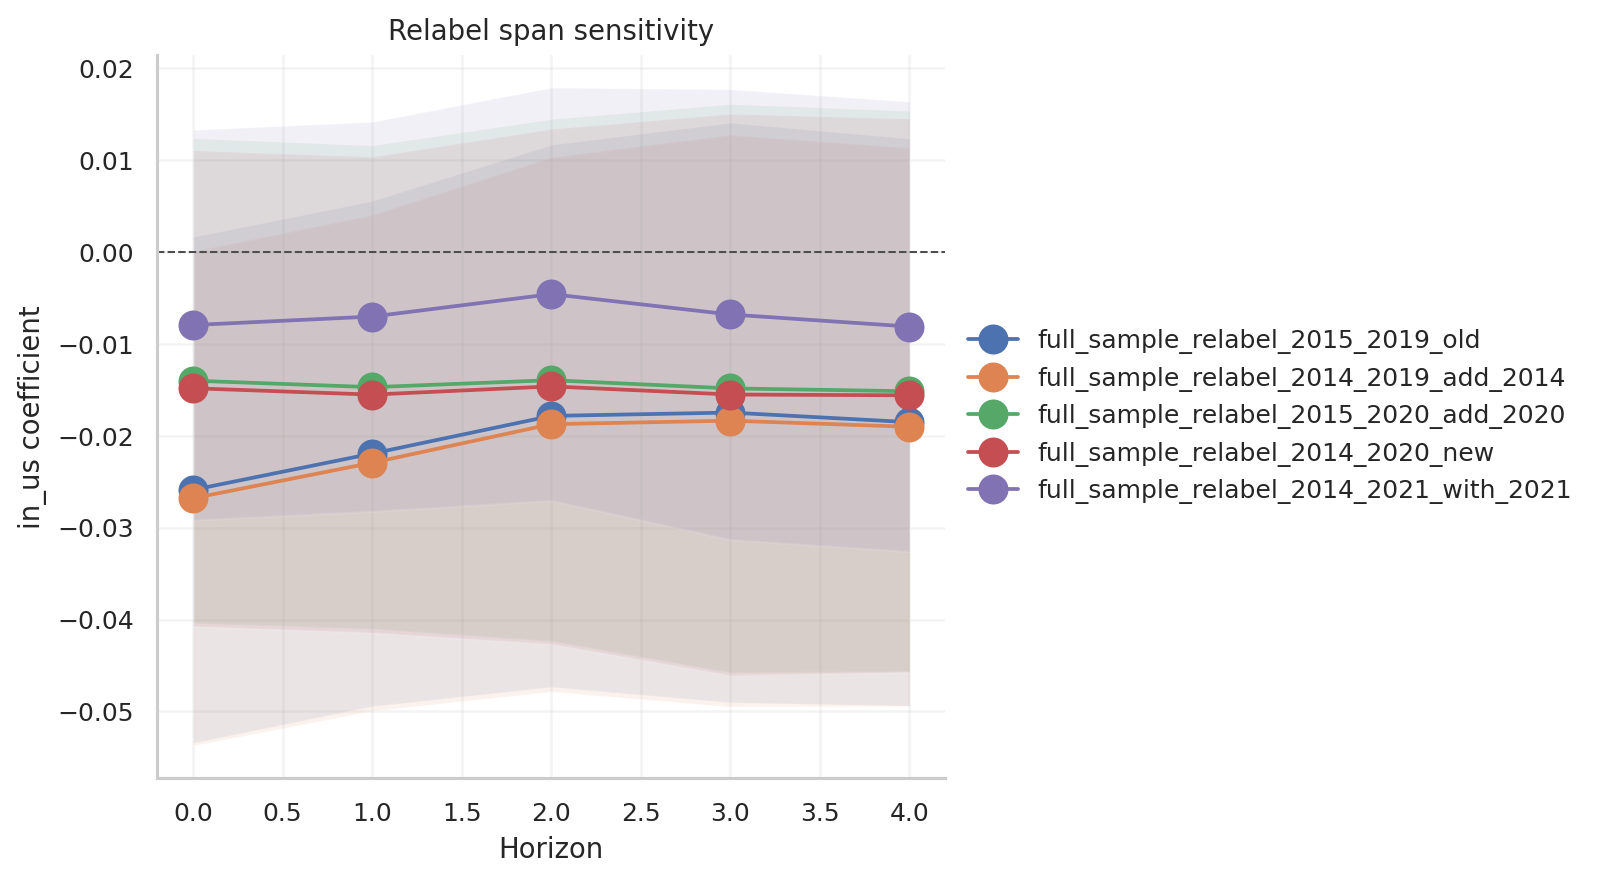

PosixPath('/home/yk0581/h1bworkers/code/output/relabel_indiv/laborlunch_20260507_individual_cache/in_us_sensitivity/relabel_span_sensitivity.png')

In [27]:
plot_profiles(relabel_results, title="Relabel span sensitivity")


## Event-time post span comparison

This checks whether the post window is driving the change. `post_max=5` matches the current pooled-post TWFE behavior when `event_window=5`; `post_max=3` matches the requested event-time restriction.


In [28]:
POST_SPAN_SPECS = []
for panel_key, relabel_span in [
    ("econ_only_old_2015_2019_h0_5", (2015, 2019)),
    ("econ_only_current_2015_2019_h0_4", (2015, 2019)),
    ("full_sample_old_2014_2021_h0_5", (2014, 2020)),
    ("full_sample_current_2014_2020_h0_4", (2014, 2020)),
]:
    for post_max in [3, 5]:
        POST_SPAN_SPECS.append(
            {
                "label": f"{panel_key}_post{post_max}",
                "panel_key": panel_key,
                "analysis_variant": "stage04_all",
                "aggregation": AGG_USER,
                "horizons": [0, 1, 2, 3, 4],
                "relabel_span": relabel_span,
                "pre_min": -5,
                "post_max": post_max,
            }
        )

post_span_results = run_specs(POST_SPAN_SPECS)
post_span_results[["label", "horizon_years", "status", "coef", "se", "raw_did", "event_min", "event_max", "n_rows", "backend"]]


[1/8] econ_only_old_2015_2019_h0_5_post3
[2/8] econ_only_old_2015_2019_h0_5_post5
[3/8] econ_only_current_2015_2019_h0_4_post3
[4/8] econ_only_current_2015_2019_h0_4_post5
[5/8] full_sample_old_2014_2021_h0_5_post3
[6/8] full_sample_old_2014_2021_h0_5_post5
[7/8] full_sample_current_2014_2020_h0_4_post3
[8/8] full_sample_current_2014_2020_h0_4_post5


,label,horizon_years,status,coef,se,raw_did,event_min,event_max,n_rows,backend
0,econ_only_old_2015_2019_h0_5_post3,0,ok,0.050551,0.037961,0.047964,-5,3,14737,pyfixest
1,econ_only_old_2015_2019_h0_5_post3,1,ok,0.055442,0.036307,0.053972,-5,3,14737,pyfixest
2,econ_only_old_2015_2019_h0_5_post3,2,ok,0.060938,0.032447,0.060768,-5,3,14737,pyfixest
3,econ_only_old_2015_2019_h0_5_post3,3,ok,0.050029,0.036160,0.048651,-5,3,14737,pyfixest
4,econ_only_old_2015_2019_h0_5_post3,4,ok,0.036954,0.033608,0.037937,-5,3,14737,pyfixest
5,econ_only_old_2015_2019_h0_5_post5,0,ok,0.072315,0.046858,0.064546,-5,5,17895,pyfixest
6,econ_only_old_2015_2019_h0_5_post5,1,ok,0.068330,0.047552,0.063091,-5,5,17895,pyfixest
7,econ_only_old_2015_2019_h0_5_post5,2,ok,0.070267,0.043705,0.066619,-5,5,17895,pyfixest
8,econ_only_old_2015_2019_h0_5_post5,3,ok,0.056955,0.045186,0.052425,-5,5,17711,pyfixest
9,econ_only_old_2015_2019_h0_5_post5,4,ok,0.046871,0.042539,0.042544,-5,5,17007,pyfixest


Saved plot: /home/yk0581/h1bworkers/code/output/relabel_indiv/laborlunch_20260507_individual_cache/in_us_sensitivity/post_event_time_span_sensitivity.png


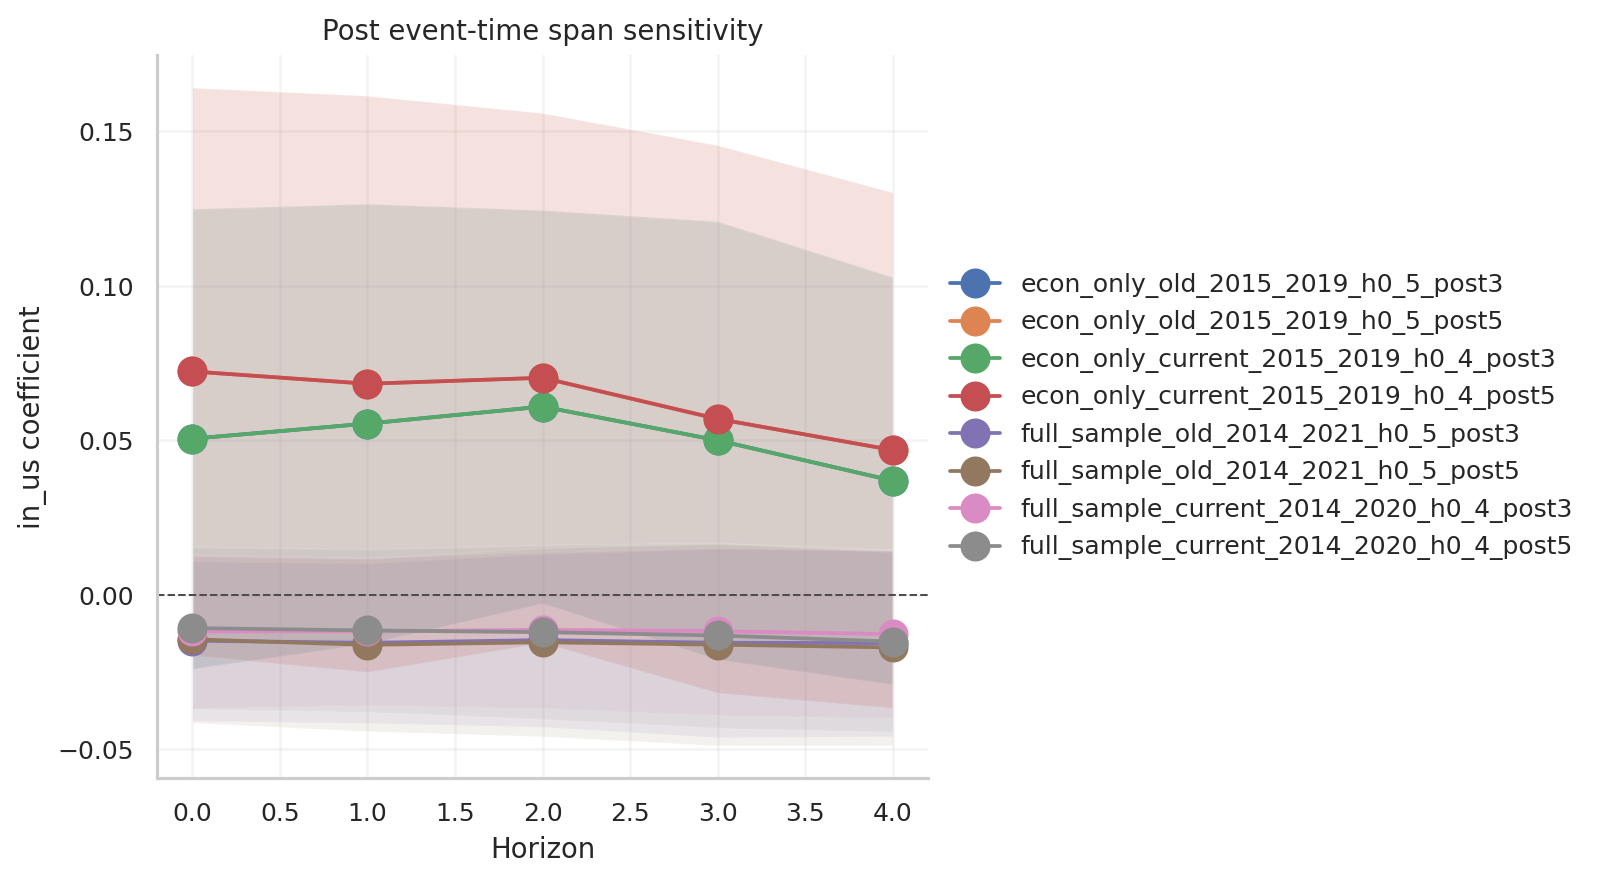

PosixPath('/home/yk0581/h1bworkers/code/output/relabel_indiv/laborlunch_20260507_individual_cache/in_us_sensitivity/post_event_time_span_sensitivity.png')

In [29]:
plot_profiles(post_span_results, title="Post event-time span sensitivity")


## Optional full factorial grid

The cell below is disabled by default because row-level full-sample regressions can take a while. Turn `RUN_FULL_FACTORIAL` to `True` if you want the full cross-product.


In [30]:
RUN_FULL_FACTORIAL = False

if RUN_FULL_FACTORIAL:
    full_specs = []
    for panel_key in PANEL_CATALOG:
        if not PANEL_CATALOG[panel_key].exists():
            continue
        for analysis_variant in ["stage04_all", "foia_linked_person_baseline"]:
            for aggregation in AGGREGATIONS:
                for horizon_name, horizons in {"h0_4": [0, 1, 2, 3, 4], "h0_5": [0, 1, 2, 3, 4, 5]}.items():
                    for relabel_name, relabel_span in RELABEL_SPANS.items():
                        for post_max in [3, 5]:
                            full_specs.append(
                                {
                                    "label": f"{panel_key}|{analysis_variant}|{aggregation}|{horizon_name}|{relabel_name}|post{post_max}",
                                    "panel_key": panel_key,
                                    "analysis_variant": analysis_variant,
                                    "aggregation": aggregation,
                                    "horizons": horizons,
                                    "relabel_span": relabel_span,
                                    "pre_min": -5,
                                    "post_max": post_max,
                                }
                            )
    full_factorial_results = run_specs(full_specs)
    display(full_factorial_results.head())
else:
    full_factorial_results = pd.DataFrame()
    print("Full factorial grid skipped. Set RUN_FULL_FACTORIAL = True to run it.")


Full factorial grid skipped. Set RUN_FULL_FACTORIAL = True to run it.


## Quick deltas

Use this to inspect horizon-level differences relative to a selected baseline label.


In [31]:
def deltas_against(df: pd.DataFrame, baseline_label: str) -> pd.DataFrame:
    work = df[df["status"].eq("ok")].copy()
    base = work[work["label"].eq(baseline_label)][["horizon_years", "coef"]].rename(columns={"coef": "baseline_coef"})
    out = work.merge(base, on="horizon_years", how="left")
    out["delta_vs_baseline"] = out["coef"] - out["baseline_coef"]
    return out.sort_values(["horizon_years", "label"])

baseline = "01_old_econ_h0_5_relabel2015_2019_post5_user_rows"
deltas_against(one_at_a_time, baseline)[["horizon_years", "label", "coef", "baseline_coef", "delta_vs_baseline", "n_rows", "n_unitids"]]


,horizon_years,label,coef,baseline_coef,delta_vs_baseline,n_rows,n_unitids
0,0,01_old_econ_h0_5_relabel2015_2019_post5_user_rows,0.072315,0.072315,0.000000,17895,40
6,0,02_old_econ_h0_4_only,0.072315,0.072315,0.000000,17895,40
11,0,03_old_econ_post3_only,0.050551,0.072315,-0.021764,14737,40
16,0,04_current_econ_rebuild_2015_2019_h0_4_post3,0.050551,0.072315,-0.021764,14737,40
21,0,05_full_sample_same_relabel2015_2019_post3,-0.025880,0.072315,-0.098195,269452,127
26,0,06_full_sample_expand_relabel2014_2020_post3,-0.014822,0.072315,-0.087137,376504,154
31,0,07_current_cache_full_sample_2014_2020_h0_4_post3,-0.011830,0.072315,-0.084145,368211,155
1,1,01_old_econ_h0_5_relabel2015_2019_post5_user_rows,0.068330,0.068330,0.000000,17895,40
7,1,02_old_econ_h0_4_only,0.068330,0.068330,0.000000,17895,40
12,1,03_old_econ_post3_only,0.055442,0.068330,-0.012888,14737,40


## Save combined outputs

The main `run_specs` helper already writes each result set to `in_us_sensitivity_results.csv` as it runs. The cell below combines the named result frames from this notebook into one CSV with a `block` column.


In [32]:
frames = []
for name, obj in [
    ("one_at_a_time", globals().get("one_at_a_time")),
    ("aggregation", globals().get("aggregation_results")),
    ("relabel", globals().get("relabel_results")),
    ("post_span", globals().get("post_span_results")),
    ("full_factorial", globals().get("full_factorial_results")),
]:
    if isinstance(obj, pd.DataFrame) and not obj.empty:
        tmp = obj.copy()
        tmp["block"] = name
        frames.append(tmp)

combined_results = pd.concat(frames, ignore_index=True, sort=False) if frames else pd.DataFrame()
combined_path = NOTEBOOK_OUT / "in_us_sensitivity_combined.csv"
if not combined_results.empty:
    combined_results.to_csv(combined_path, index=False)
combined_path, combined_results.shape


(PosixPath('/home/yk0581/h1bworkers/code/output/relabel_indiv/laborlunch_20260507_individual_cache/in_us_sensitivity/in_us_sensitivity_combined.csv'),
 (131, 30))